# Plotting training results

This notebook serves as a visualization tool for the training results of the **FlowerLLM** training results.
It reads the metric from the training curves directly from Wandb and collect them in `pandas` data frames ready to be analyzed and plotted.

In [17]:
# Imports
import numpy as np
from matplotlib.rcsetup import cycler
import wandb
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "bold"
# Colorblind palette, subsample 4 of them
list_of_colors = sns.color_palette("colorblind")
list_of_colors = np.random.choice(len(list_of_colors), 4, replace=False)
plt.rcParams["axes.prop_cycle"] = cycler(
    color=sns.color_palette("colorblind")[:4], linestyle=["-", "--", ":", "-."]
)
# Bolded axis labels
plt.rcParams["axes.labelweight"] = "bold"
# # Cycler for line styles
# plt.rcParams["lines.linestyle"] = cycle(["-", "--", "-.", ":"])

In [18]:
# Set the run_id to be retrieved
run_id_dict = {
    "fed-1B-short": [
        ("fed-1B-20240322_221900-fix-nesto", 8),
    ],
    "fed-1B-long": [
        ("fed-1B-20240314_232607", 8),
    ],
    "cen-1B": [
        ("centralised-1B-20240229_104204", 0),
    ],
    "fed-350M": [
        ("fed-350M-20240506_204125", 8),
        ("fed-350M-20240505_100605", 8),
    ],
    "cen-350M": [
        ("centralised-350M-20240305_191112", 0),
    ],
    "fed-160M": [],
    "cen-160M": [],
    "fed-125M": [
        ("fed-125M-20240502_203012-continue-3", 8),
        ("fed-125M-20240502_203012", 8),
    ],
    "cen-125M": [],
    "fed-75M": [("fed-75M-20240506_234900", 8)],
    "cen-75M": [],
}

In [19]:
# Server metrics columns
server_metrics_columns = [
    # Train-specific metrics
    "LanguageCrossEntropy",
    "LanguagePerplexity",
    # Val-specific metrics
    "ValLanguageCrossEntropy",
    "ValLanguagePerplexity",
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Client-side bookkeeping
    "client/eval_init_time",
    "client/eval_metrics_collection_time",
    "client/eval_time",
    "client/eval_trainer_closing_time",
    "client/fit_get_parameters_time",
    "client/fit_init_time",
    "client/fit_metrics_collection_time",
    "client/fit_time",
    "client/fit_trainer_closing_time",
    # Client-side metrics
    "client/l2_norm_pseudo_gradient",
    "client_state_acc",
    "distributed_loss",
    # Node-side bookkeeping
    "node_eval_time_s",
    "node_training_time_s",
    # Server-side bookkeeping
    "server/evaluate_round_time",
    "server/evaluate_time",
    "server/first_check_nm_time",
    "server/fit_round_time",
    "server/round_time",
    "server/second_check_nm_time",
    # Server-side computed norms
    "server/l2_norm_fedavg_result",
    "server/l2_norm_model",
    "server/l2_norm_momentum_vector",
    "server/l2_norm_pseudo_gradient",
    # Step
    "step",
    # Worker-side bookkeeping
    "worker/partial_aggregation_time",
]

In [20]:
# Client metrics columns
client_metrics_columns = [
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Activation norms
    "activations/l2_norm/full_model_input",
    "activations/l2_norm/full_model_output",
    # CID
    "client_id",
    # Momentum, gradient and model norms
    "l2_norm/grad/global",
    "l2_norm/moment/global",
    "l2_norm/param/global",
    "l2_norm/update/global",
    # Train loss
    "loss/train/total",
    # LR
    "lr-DecoupledAdamW/group0",
    # Memory metrics
    "memory/alloc_retries",
    "memory/current_active_mem",
    "memory/current_allocated_mem",
    "memory/current_inactive_mem",
    "memory/current_reserved_mem",
    "memory/peak_active_mem",
    "memory/peak_allocated_mem",
    "memory/peak_inactive_mem",
    "memory/peak_reserved_mem",
    "metrics/train/LanguageCrossEntropy",
    "metrics/train/LanguagePerplexity",
    # Step
    "step",
    # Throughput metrics
    "throughput/batches_per_sec",
    "throughput/device/batches_per_sec",
    "throughput/device/flops_per_sec",
    "throughput/device/mfu",
    "throughput/device/samples_per_sec",
    "throughput/device/tokens_per_sec",
    "throughput/flops_per_sec",
    "throughput/samples_per_sec",
    "throughput/tokens_per_sec",
    # Time metrics
    "time/batch",
    "time/batch_in_epoch",
    "time/epoch",
    "time/remaining_estimate",
    "time/sample",
    "time/sample_in_epoch",
    "time/token",
    "time/token_in_epoch",
    "time/total",
    "time/train",
    "time/val",
    # Microbatch size
    "trainer/device_train_microbatch_size",
]

In [21]:
def download_metrics(
    run_id: str, n_clients: int, drop_layers: bool = True
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api()
    # Get the run object
    server_run = api.run(f"camlsys/pollen-llm/{run_id}")
    # Get the metrics
    server_metrics = server_run.scan_history()
    # Convert the metrics to a pandas data frame
    server_metrics_df = pd.DataFrame(server_metrics)
    # Drop the layers columns if needed
    if drop_layers:
        layer_columns = [col for col in server_metrics_df.columns if "layer" in col]
        server_metrics_df = server_metrics_df.drop(columns=layer_columns)
    # Add the `step` column based on the index
    server_metrics_df["step"] = server_metrics_df.index
    # Get clients metrics
    clients_metrics_df_list: list[pd.DataFrame] = []
    for i in range(n_clients):
        # Get the run object
        client_run = api.run(f"camlsys/pollen-llm/{run_id}_client_{i}")
        # Get the metrics
        client_metrics = client_run.scan_history()
        # Convert the metrics to a pandas data frame
        client_metrics_df = pd.DataFrame(client_metrics)
        # Drop the layers columns if needed
        if drop_layers:
            layer_columns = [col for col in client_metrics_df.columns if "layer" in col]
            client_metrics_df = client_metrics_df.drop(columns=layer_columns)
        # Add the `step` column based on the index
        client_metrics_df["step"] = client_metrics_df.index
        # Add the `client_id` column based on the current client_id
        client_metrics_df["client_id"] = i
        # Append the client metrics to the list
        clients_metrics_df_list.append(client_metrics_df)
    # Concatenate the clients metrics
    clients_metrics_df = pd.concat(clients_metrics_df_list)
    # Return the metrics data frame
    return server_metrics_df, clients_metrics_df

In [22]:
data_frames = download_metrics(
    run_id_dict["fed-1B-long"][0][0], run_id_dict["fed-1B-long"][0][1]
)
server_data_frame, clients_data_frame = data_frames[0], data_frames[1]

In [23]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-1B-long"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)

In [24]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-350M"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)

In [25]:
def plot_single_federated_run_ppl(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="ValLanguagePerplexity",
        label="Server Validation PPL",
        alpha=0.5,
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="LanguagePerplexity",
        label="Mean Train PPL",
        alpha=0.5,
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="metrics/train/LanguagePerplexity",
        label="Client Train PPL",
        alpha=0.5,
    )
    # Set mthe maximum y-axis limit to 500
    plt.ylim(0, 200)
    plt.grid()
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("PPL")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

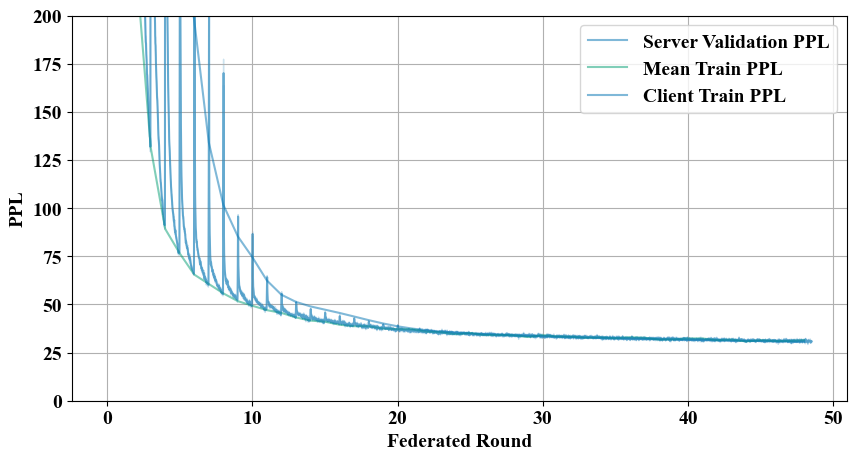

In [26]:
plot_single_federated_run_ppl(server_data_frame, clients_data_frame)

In [27]:
def plot_single_federated_run_l2_model(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label=r"L2 norm $\theta_{g}$",
        alpha=0.5,
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_fedavg_result",
        label=r"L2 norm $\theta_{avg}$",
        alpha=0.5,
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/param/global",
        label=r"Avg. L2 norm $\theta_{c}$",
        alpha=0.5,
    )
    # Set mthe maximum y-axis limit to 500
    # plt.ylim(0, 200)
    plt.grid()
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("PPL")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

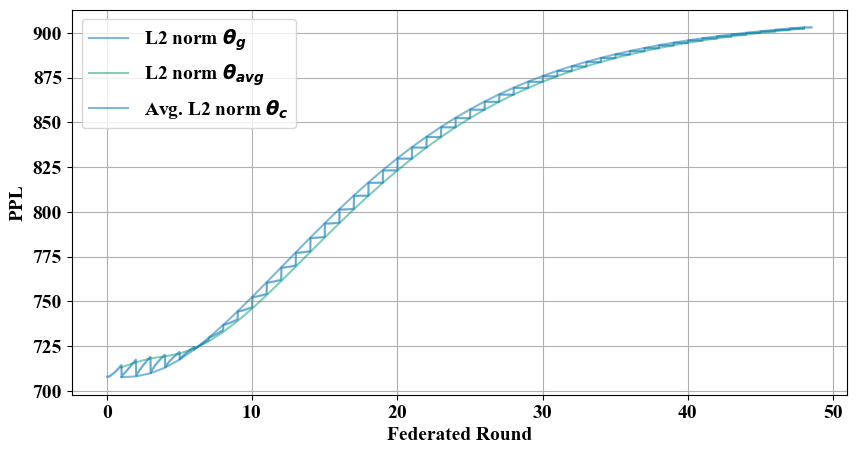

In [28]:
plot_single_federated_run_l2_model(server_data_frame, clients_data_frame)

In [29]:
def plot_single_federated_run_l2_momentum(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_momentum_vector",
        label=r"L2 norm $v_{g}$",
        alpha=0.5,
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label=r"L2 norm $\theta_{g}$",
        alpha=0.5,
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/moment/global",
        label=r"Avg. L2 norm $v_{c}$",
        alpha=0.5,
    )
    # Set mthe maximum y-axis limit to 500
    # plt.ylim(0, 200)
    plt.grid()
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("PPL")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

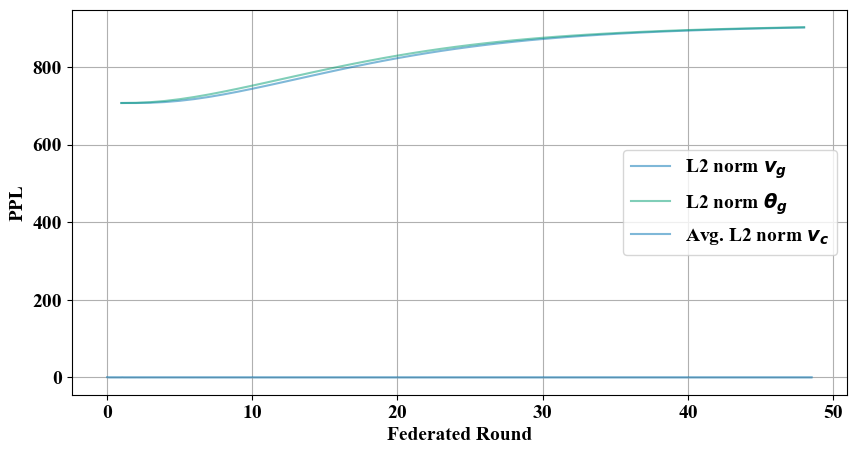

In [30]:
plot_single_federated_run_l2_momentum(server_data_frame, clients_data_frame)

In [31]:
def plot_single_federated_run_l2_gradient(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    fig = plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_pseudo_gradient",
        label=r"L2 norm $\Delta\theta_{g}$",
        alpha=0.5,
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/grad/global",
        label=r"Avg. L2 norm $\Delta\theta_{c}$",
        alpha=0.5,
    )
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/update/global",
        label=r"Avg. L2 norm $\Delta\theta_{1c}$",
        alpha=0.5,
    )
    # Set mthe maximum y-axis limit to 500
    # plt.ylim(0, 200)
    plt.grid()
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("PPL")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

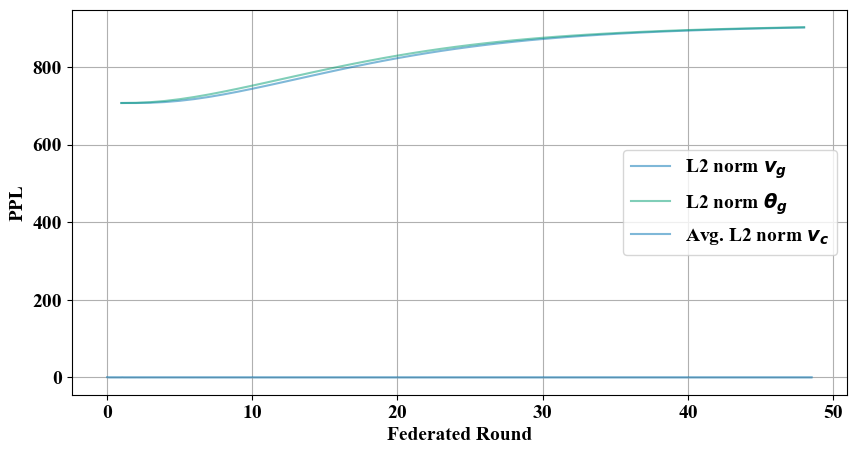

In [32]:
plot_single_federated_run_l2_momentum(server_data_frame, clients_data_frame)